<a href="https://colab.research.google.com/github/S-0120/XAI/blob/main/ember.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# ============================================
# MASTER CELL — HAR SESSION START PE RUN KARO
# ============================================
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import joblib
import tensorflow as tf

# Load data
print("Loading data...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Data Loaded! X_train: {X_train_selected.shape}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
✅ Data Loaded! X_train: (48000, 100)


In [ ]:
import os
os.makedirs('/content/drive/MyDrive/XC_MD_Project/ember2018', exist_ok=True)
os.makedirs('/content/drive/MyDrive/XC_MD_Project/models', exist_ok=True)
os.makedirs('/content/drive/MyDrive/XC_MD_Project/results', exist_ok=True)
os.makedirs('/content/drive/MyDrive/XC_MD_Project/notebooks', exist_ok=True)
print("✅ Folders created!")

✅ Folders created!


In [ ]:
!cp -r ember2018/ /content/drive/MyDrive/XC_MD_Project/
print("✅ Saved to Drive!")

cp: cannot stat 'ember2018/': No such file or directory
✅ Saved to Drive!


In [ ]:
!pip install lief
print("✅ lief installed!")

✅ lief installed!


In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import gc

parquet_file = pq.ParquetFile(
    "/content/drive/MyDrive/XC_MD_Project/ember2018/train_ember_2018_v2_features.parquet"
)

benign_rows = []
malware_rows = []

for batch in parquet_file.iter_batches(batch_size=1000):
    chunk = batch.to_pandas()
    benign_rows.append(chunk[chunk['Label'] == 0.0])
    malware_rows.append(chunk[chunk['Label'] == 1.0])

    b_count = sum(len(b) for b in benign_rows)
    m_count = sum(len(m) for m in malware_rows)

    if b_count >= 25000 and m_count >= 25000:
        break

    del chunk
    gc.collect()

benign_df = pd.concat(benign_rows).head(25000)
malware_df = pd.concat(malware_rows).head(25000)
train_df = pd.concat([benign_df, malware_df]).sample(frac=1, random_state=42)

train_df.to_csv("/content/drive/MyDrive/XC_MD_Project/ember_train.csv", index=False)
print(f"✅ Train CSV saved! Shape: {train_df.shape}")

✅ Train CSV saved! Shape: (50000, 2382)


In [ ]:
import pyarrow.parquet as pq
import pandas as pd
import gc

parquet_file = pq.ParquetFile(
    "/content/drive/MyDrive/XC_MD_Project/ember2018/test_ember_2018_v2_features.parquet"
)

benign_rows = []
malware_rows = []

for batch in parquet_file.iter_batches(batch_size=1000):
    chunk = batch.to_pandas()
    benign_rows.append(chunk[chunk['Label'] == 0.0])
    malware_rows.append(chunk[chunk['Label'] == 1.0])

    b_count = sum(len(b) for b in benign_rows)
    m_count = sum(len(m) for m in malware_rows)

    if b_count >= 5000 and m_count >= 5000:
        break

    del chunk
    gc.collect()

benign_df = pd.concat(benign_rows).head(5000)
malware_df = pd.concat(malware_rows).head(5000)
test_df = pd.concat([benign_df, malware_df]).sample(frac=1, random_state=42)

test_df.to_csv("/content/drive/MyDrive/XC_MD_Project/ember_test.csv", index=False)
print(f"✅ Test CSV saved! Shape: {test_df.shape}")

✅ Test CSV saved! Shape: (10000, 2382)


Data preprocessing-separate features and labesl

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_classif
import joblib

# ================================
# STEP 1: LOAD CSVs
# ================================
print("Loading CSVs...")
train_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_test.csv")
print(f"✅ Loaded! Train: {train_df.shape}, Test: {test_df.shape}")

# ================================
# STEP 2: FEATURES & LABEL ALAG
# ================================
X_train = train_df.drop(columns=['Label'])
y_train = train_df['Label']
X_test = test_df.drop(columns=['Label'])
y_test = test_df['Label']
print(f"✅ Split Done!")

# Save karo
y_train.to_csv("/content/drive/MyDrive/XC_MD_Project/y_train.csv", index=False)
y_test.to_csv("/content/drive/MyDrive/XC_MD_Project/y_test.csv", index=False)
print("✅ Labels Saved!")

# ================================
# STEP 3: NORMALIZE
# ================================
print("Normalizing...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print(f"✅ Normalization Done!")

# Save karo
joblib.dump(scaler, "/content/drive/MyDrive/XC_MD_Project/models/scaler.pkl")
print("✅ Scaler Saved!")

# ================================
# STEP 4: FEATURE SELECTION
# ================================
print("Selecting top 100 features... (2-3 min lagenge)")
selector = SelectKBest(mutual_info_classif, k=100)
X_train_selected = selector.fit_transform(X_train_scaled, y_train)
X_test_selected = selector.transform(X_test_scaled)
print(f"✅ Feature Selection Done!")
print(f"X_train: {X_train_selected.shape}")
print(f"X_test: {X_test_selected.shape}")

# Save karo
pd.DataFrame(X_train_selected).to_csv("/content/drive/MyDrive/XC_MD_Project/X_train_selected.csv", index=False)
pd.DataFrame(X_test_selected).to_csv("/content/drive/MyDrive/XC_MD_Project/X_test_selected.csv", index=False)
joblib.dump(selector, "/content/drive/MyDrive/XC_MD_Project/models/selector.pkl")
print("✅ Selected Features Saved!")

print("\n🎉 Preprocessing Complete & Saved!")

Loading CSVs...
✅ Loaded! Train: (50000, 2382), Test: (10000, 2382)
✅ Split Done!
✅ Labels Saved!
Normalizing...
✅ Normalization Done!
✅ Scaler Saved!
Selecting top 100 features... (2-3 min lagenge)


KeyboardInterrupt: 

In [ ]:
import os

print("=== XC_MD_Project Files ===")
for f in os.listdir("/content/drive/MyDrive/XC_MD_Project/"):
    print(f)

print("\n=== Models Folder ===")
for f in os.listdir("/content/drive/MyDrive/XC_MD_Project/models/"):
    print(f)

In [ ]:
import shutil
import os

# Sirf scaler aur selector move karo
shutil.move(
    "/content/drive/MyDrive/XC_MD_Project/models/scaler.pkl",
    "/content/drive/MyDrive/XC_MD_Project/preprocessing/scaler.pkl"
)
shutil.move(
    "/content/drive/MyDrive/XC_MD_Project/models/selector.pkl",
    "/content/drive/MyDrive/XC_MD_Project/preprocessing/selector.pkl"
)

print("✅ Done!")

print("\n=== Preprocessing Folder ===")
for f in os.listdir("/content/drive/MyDrive/XC_MD_Project/preprocessing/"):
    print(f)

baseline models

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load data
print("Loading data...")
X_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected.csv")
X_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test.csv").values.ravel()
print(f"✅ Data Loaded! X_train: {X_train.shape}")

random-forest


In [ ]:
# Random Forest - Train + Evaluate
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("✅ Random Forest Trained!")

# Evaluate
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_pred))

# Save
joblib.dump(rf_model, "/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
print("✅ RF Model Saved!")

without normalization

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Raw data load karo
import pandas as pd
print("Loading raw data...")
train_raw = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_train.csv")
test_raw = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_test.csv")

X_train_raw = train_raw.drop(columns=['Label'])
y_train_raw = train_raw['Label']
X_test_raw = test_raw.drop(columns=['Label'])
y_test_raw = test_raw['Label']

print("Training Random Forest on raw data...")
rf_model2 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model2.fit(X_train_raw, y_train_raw)

rf_pred2 = rf_model2.predict(X_test_raw)
rf_acc2 = accuracy_score(y_test_raw, rf_pred2)
print(f"✅ Random Forest Accuracy: {rf_acc2*100:.2f}%")
print(classification_report(y_test_raw, rf_pred2))

xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train_raw, y_train_raw)

xgb_pred = xgb_model.predict(X_test_raw)
xgb_acc = accuracy_score(y_test_raw, xgb_pred)
print(f"✅ XGBoost Accuracy: {xgb_acc*100:.2f}%")
print(classification_report(y_test_raw, xgb_pred))

# Save
joblib.dump(xgb_model, "/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
print("✅ XGBoost Model Saved!")

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import pandas as pd
import joblib

# Dono CSVs ek saath load karo
print("Loading data...")
train_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_test.csv")

# Dono ko combine karo
full_df = pd.concat([train_df, test_df], ignore_index=True)

X = full_df.drop(columns=['Label'])
y = full_df['Label']

# 80/20 split karo properly
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ X_train: {X_train.shape}")
print(f"✅ X_test: {X_test.shape}")
print(f"Train - Malware: {(y_train==1).sum()}, Benign: {(y_train==0).sum()}")
print(f"Test  - Malware: {(y_test==1).sum()}, Benign: {(y_test==0).sum()}")

# Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_pred))

joblib.dump(rf_model, "/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
print("✅ RF Model Saved!")

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import joblib

# ================================
# STEP 1: LOAD DATA
# ================================
print("Loading data...")
train_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_train.csv")
test_df = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/ember_test.csv")

# Combine & Split
full_df = pd.concat([train_df, test_df], ignore_index=True)
X = full_df.drop(columns=['Label'])
y = full_df['Label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"✅ Data Loaded! X_train: {X_train.shape}")

# Save splits
y_train.to_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv", index=False)
y_test.to_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv", index=False)
print("✅ Labels Saved!")

# ================================
# STEP 2: FEATURE SELECTION
# ================================
print("Selecting top 100 features...")
rf_temp = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf_temp.fit(X_train, y_train)

importances = rf_temp.feature_importances_
top_100_idx = np.argsort(importances)[-100:]

X_train_selected = X_train.iloc[:, top_100_idx]
X_test_selected = X_test.iloc[:, top_100_idx]
print(f"✅ Top 100 Features Selected!")

# Save selected features
pd.DataFrame(X_train_selected).to_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv", index=False)
pd.DataFrame(X_test_selected).to_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv", index=False)
joblib.dump(top_100_idx, "/content/drive/MyDrive/XC_MD_Project/preprocessing/top_100_idx.pkl")
print("✅ Selected Features Saved!")

random forest -baseline

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Saved files se load karo
print("Loading saved files...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Loaded! X_train: {X_train_selected.shape}")

# Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)
rf_pred = rf_model.predict(X_test_selected)
rf_acc = accuracy_score(y_test, rf_pred)
print(f"✅ Random Forest Accuracy: {rf_acc*100:.2f}%")
print(classification_report(y_test, rf_pred))

joblib.dump(rf_model, "/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
print("✅ RF Model Saved!")

xgboost

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib

print("Training XGBoost...")
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    eval_metric='logloss'
)
xgb_model.fit(X_train_selected, y_train)
xgb_pred = xgb_model.predict(X_test_selected)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"✅ XGBoost Accuracy: {xgb_acc*100:.2f}%")
print(classification_report(y_test, xgb_pred))

joblib.dump(xgb_model, "/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
print("✅ XGBoost Model Saved!")

In [ ]:
# Results log karo
import pandas as pd

results = {
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [rf_acc*100, xgb_acc*100]
}

results_df = pd.DataFrame(results)
results_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/baseline_results.csv", index=False)
print(results_df)
print("✅ Results Saved!")

NameError: name 'rf_acc' is not defined

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ================================
# GRAPH 1: Accuracy Comparison
# ================================
models = ['Random Forest', 'XGBoost']
accuracies = [95.75, 96.96]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accuracies, color=['#2196F3', '#4CAF50'], width=0.4)
plt.ylim(90, 100)
plt.title('Baseline Model Accuracy Comparison', fontsize=14)
plt.ylabel('Accuracy (%)')
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc}%', ha='center', fontsize=12, fontweight='bold')
plt.axhline(y=95, color='red', linestyle='--', label='Target (95%)')
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Accuracy Graph Saved!")

# ================================
# GRAPH 2: Confusion Matrix - RF
# ================================
cm_rf = confusion_matrix(y_test, rf_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.title('Confusion Matrix - Random Forest', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/cm_rf.png", dpi=150)
plt.show()
print("✅ RF Confusion Matrix Saved!")

# ================================
# GRAPH 3: Confusion Matrix - XGBoost
# ================================
cm_xgb = confusion_matrix(y_test, xgb_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.title('Confusion Matrix - XGBoost', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/cm_xgb.png", dpi=150)
plt.show()
print("✅ XGBoost Confusion Matrix Saved!")

svm with normalize data

In [ ]:
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Normalize karo pehle
print("Normalizing...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)
print("✅ Normalized!")

# LinearSVC Train
print("Training SVM...")
svm_model = CalibratedClassifierCV(LinearSVC(random_state=42, max_iter=2000))
svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"✅ SVM Accuracy: {svm_acc*100:.2f}%")
print(classification_report(y_test, svm_pred))

joblib.dump(svm_model, "/content/drive/MyDrive/XC_MD_Project/models/svm_model.pkl")
joblib.dump(scaler, "/content/drive/MyDrive/XC_MD_Project/preprocessing/scaler_svm.pkl")
print("✅ SVM Model Saved!")

Normalizing...
✅ Normalized!
Training SVM...
✅ SVM Accuracy: 86.65%
              precision    recall  f1-score   support

         0.0       0.90      0.82      0.86      6000
         1.0       0.84      0.91      0.87      6000

    accuracy                           0.87     12000
   macro avg       0.87      0.87      0.87     12000
weighted avg       0.87      0.87      0.87     12000

✅ SVM Model Saved!


cnn-reshape the data

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Pehle sahi se scale karo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

print(f"X_train_scaled shape: {X_train_scaled.shape}")  # (48000, 100) hona chahiye

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 100, 1)
X_test_cnn = X_test_scaled.reshape(-1, 100, 1)
print(f"✅ Reshaped! X_train: {X_train_cnn.shape}")  # (48000, 100, 1) hona chahiye

# CNN Model
model_cnn = Sequential([
    Conv1D(64, kernel_size=3, activation='relu', input_shape=(100, 1)),
    MaxPooling1D(pool_size=2),
    Conv1D(128, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train
print("Training CNN...")
history = model_cnn.fit(
    X_train_cnn, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

# Evaluate
cnn_pred = (model_cnn.predict(X_test_cnn) > 0.5).astype(int).ravel()
cnn_acc = accuracy_score(y_test, cnn_pred)
print(f"✅ CNN Accuracy: {cnn_acc*100:.2f}%")
print(classification_report(y_test, cnn_pred))

# Save
model_cnn.save("/content/drive/MyDrive/XC_MD_Project/models/cnn_model.h5")
print("✅ CNN Model Saved!")

X_train_scaled shape: (48000, 100)
✅ Reshaped! X_train: (48000, 100, 1)
Training CNN...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


675/675 ━━━━━━━━━━━━━━━━━━━━ 22s 30ms/step - accuracy: 0.8899 - loss: 0.2605 - val_accuracy: 0.9190 - val_loss: 0.1949
Epoch 2/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9225 - loss: 0.1912 - val_accuracy: 0.9306 - val_loss: 0.1780
Epoch 3/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9327 - loss: 0.1704 - val_accuracy: 0.9421 - val_loss: 0.1546
Epoch 4/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9391 - loss: 0.1544 - val_accuracy: 0.9413 - val_loss: 0.1493
Epoch 5/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 22s 33ms/step - accuracy: 0.9435 - loss: 0.1428 - val_accuracy: 0.9450 - val_loss: 0.1483
Epoch 6/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 41s 33ms/step - accuracy: 0.9476 - loss: 0.1316 - val_accuracy: 0.9463 - val_loss: 0.1447
Epoch 7/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9510 - loss: 0.1247 - val_accuracy: 0.9510 - val_loss: 0.1322
Epoch 8/10
675/675 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9554 - loss: 0.1147 - val_accurac

              precision    recall  f1-score   support

         0.0       0.93      0.96      0.94      6000
         1.0       0.96      0.93      0.94      6000

    accuracy                           0.94     12000
   macro avg       0.94      0.94      0.94     12000
weighted avg       0.94      0.94      0.94     12000

✅ CNN Model Saved!


stack ensembling

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report
import joblib
import numpy as np

# ================================
# STEP 1: RF aur XGBoost dobara train karo
# ================================
print("Training RF on 100 features...")
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_selected, y_train)
print(f"✅ RF Accuracy: {accuracy_score(y_test, rf_model.predict(X_test_selected))*100:.2f}%")
joblib.dump(rf_model, "/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")

print("Training XGBoost on 100 features...")
xgb_model = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
xgb_model.fit(X_train_selected, y_train)
print(f"✅ XGBoost Accuracy: {accuracy_score(y_test, xgb_model.predict(X_test_selected))*100:.2f}%")
joblib.dump(xgb_model, "/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")

# ================================
# STEP 2: BASE PREDICTIONS
# ================================
print("Getting base predictions...")
rf_train_pred = rf_model.predict_proba(X_train_selected)[:, 1]
xgb_train_pred = xgb_model.predict_proba(X_train_selected)[:, 1]
cnn_train_pred = cnn_model.predict(X_train_cnn).ravel()

rf_test_pred = rf_model.predict_proba(X_test_selected)[:, 1]
xgb_test_pred = xgb_model.predict_proba(X_test_selected)[:, 1]
cnn_test_pred = cnn_model.predict(X_test_cnn).ravel()
print("✅ Base Predictions Done!")

# ================================
# STEP 3: META LAYER
# ================================
X_train_meta = np.column_stack([rf_train_pred, xgb_train_pred, cnn_train_pred])
X_test_meta = np.column_stack([rf_test_pred, xgb_test_pred, cnn_test_pred])

print("Training Meta Layer (LightGBM)...")
meta_model = LGBMClassifier(n_estimators=100, random_state=42)
meta_model.fit(X_train_meta, y_train)
meta_pred = meta_model.predict(X_test_meta)
meta_acc = accuracy_score(y_test, meta_pred)
print(f"✅ Stacking Ensemble Accuracy: {meta_acc*100:.2f}%")
print(classification_report(y_test, meta_pred))

joblib.dump(meta_model, "/content/drive/MyDrive/XC_MD_Project/models/meta_model.pkl")
print("✅ Meta Model Saved!")

Training RF on 100 features...
✅ RF Accuracy: 96.18%
Training XGBoost on 100 features...
✅ XGBoost Accuracy: 96.96%
Getting base predictions...
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
✅ Base Predictions Done!
Training Meta Layer (LightGBM)...
[LightGBM] [Info] Number of positive: 24000, number of negative: 24000
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002988 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 591
[LightGBM] [Info] Number of data points in the train set: 48000, number of used features: 3
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positiv

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


using logistic regression

In [ ]:
from sklearn.linear_model import LogisticRegression

print("Training Meta Layer (Logistic Regression)...")
meta_model_lr = LogisticRegression(random_state=42, max_iter=1000)
meta_model_lr.fit(X_train_meta, y_train)
meta_pred_lr = meta_model_lr.predict(X_test_meta)
meta_acc_lr = accuracy_score(y_test, meta_pred_lr)
print(f"✅ Stacking Ensemble (LR) Accuracy: {meta_acc_lr*100:.2f}%")
print(classification_report(y_test, meta_pred_lr))

joblib.dump(meta_model_lr, "/content/drive/MyDrive/XC_MD_Project/models/meta_model_lr.pkl")
print("✅ LR Meta Model Saved!")

Training Meta Layer (Logistic Regression)...
✅ Stacking Ensemble (LR) Accuracy: 96.73%
              precision    recall  f1-score   support

         0.0       0.97      0.96      0.97      6000
         1.0       0.97      0.97      0.97      6000

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000

✅ LR Meta Model Saved!


In [ ]:
import pandas as pd
import numpy as np
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

# Load data
print("Loading data...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Loaded! X_train: {X_train_selected.shape}")

# LightGBM Train
print("Training LightGBM...")
lgbm_model = LGBMClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1)
lgbm_model.fit(X_train_selected, y_train)
lgbm_pred = lgbm_model.predict(X_test_selected)
lgbm_acc = accuracy_score(y_test, lgbm_pred)
print(f"✅ LightGBM Accuracy: {lgbm_acc*100:.2f}%")
print(classification_report(y_test, lgbm_pred))

joblib.dump(lgbm_model, "/content/drive/MyDrive/XC_MD_Project/models/lgbm_model.pkl")
print("✅ LightGBM Saved!")

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
import joblib

print("✅ Imports Done!")

✅ Imports Done!


k fold cross validation

In [ ]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import joblib

# ================================
# K-Fold Setup
# ================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X = np.array(X_train_selected)
y = y_train

fold_accuracies = []
fold = 1

print("Starting 5-Fold Cross Validation...")
print("="*50)

for train_idx, val_idx in kf.split(X, y):
    print(f"\nFold {fold}/5...")

    X_fold_train, X_fold_val = X[train_idx], X[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RF
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_fold_train, y_fold_train)

    # XGB
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb.fit(X_fold_train, y_fold_train)

    # CNN
    scaler = StandardScaler()
    X_fold_train_scaled = scaler.fit_transform(X_fold_train)
    X_fold_val_scaled = scaler.transform(X_fold_val)

    X_fold_train_cnn = X_fold_train_scaled.reshape(-1, 100, 1)
    X_fold_val_cnn = X_fold_val_scaled.reshape(-1, 100, 1)

    cnn = tf.keras.models.load_model("/content/drive/MyDrive/XC_MD_Project/models/cnn_model.h5")

    # Meta features
    rf_pred = rf.predict_proba(X_fold_train)[:, 1]
    xgb_pred = xgb.predict_proba(X_fold_train)[:, 1]
    cnn_pred = cnn.predict(X_fold_train_cnn).ravel()

    rf_val = rf.predict_proba(X_fold_val)[:, 1]
    xgb_val = xgb.predict_proba(X_fold_val)[:, 1]
    cnn_val = cnn.predict(X_fold_val_cnn).ravel()

    X_meta_train = np.column_stack([rf_pred, xgb_pred, cnn_pred])
    X_meta_val = np.column_stack([rf_val, xgb_val, cnn_val])

    # Meta LR
    lr = LogisticRegression(C=10, random_state=42, max_iter=1000)
    lr.fit(X_meta_train, y_fold_train)

    val_pred = lr.predict(X_meta_val)
    acc = accuracy_score(y_fold_val, val_pred)
    fold_accuracies.append(acc)

    print(f"✅ Fold {fold} Accuracy: {acc*100:.2f}%")
    fold += 1

print("\n" + "="*50)
print(f"✅ Mean Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print(f"✅ Std Deviation: {np.std(fold_accuracies)*100:.2f}%")
print(f"✅ All Folds: {[f'{a*100:.2f}%' for a in fold_accuracies]}")

Starting 5-Fold Cross Validation...

Fold 1/5...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 7s 6ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Fold 1 Accuracy: 96.05%

Fold 2/5...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
✅ Fold 2 Accuracy: 96.11%

Fold 3/5...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
✅ Fold 3 Accuracy: 95.82%

Fold 4/5...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Fold 4 Accuracy: 96.66%

Fold 5/5...


1200/1200 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
300/300 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
✅ Fold 5 Accuracy: 96.10%

✅ Mean Accuracy: 96.15%
✅ Std Deviation: 0.27%
✅ All Folds: ['96.05%', '96.11%', '95.82%', '96.66%', '96.10%']


In [ ]:
import os
import joblib
import pandas as pd

# Folder banao
os.makedirs("/content/drive/MyDrive/XC_MD_Project/models/kfold", exist_ok=True)
print("✅ Folder Created!")

# Results save karo
fold_accuracies = [96.05, 96.11, 95.82, 96.66, 96.10]
results_df = pd.DataFrame({
    'Fold': [1, 2, 3, 4, 5],
    'Accuracy': fold_accuracies
})
results_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/kfold_results.csv", index=False)
print("✅ Results Saved!")
print(results_df)

✅ Folder Created!
✅ Results Saved!
   Fold  Accuracy
0     1     96.05
1     2     96.11
2     3     95.82
3     4     96.66
4     5     96.10


In [ ]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
import joblib

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X = np.array(X_train_selected)
y = y_train

fold_accuracies = []
fold = 1

print("Starting 5-Fold Cross Validation...")
print("="*50)

for train_idx, val_idx in kf.split(X, y):
    print(f"\nFold {fold}/5...")

    X_fold_train, X_fold_val = X[train_idx], X[val_idx]
    y_fold_train, y_fold_val = y[train_idx], y[val_idx]

    # RF
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_fold_train, y_fold_train)

    # XGB
    xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1,
                        random_state=42, n_jobs=-1, eval_metric='logloss')
    xgb.fit(X_fold_train, y_fold_train)

    # Meta features
    X_meta_train = np.column_stack([
        rf.predict_proba(X_fold_train)[:, 1],
        xgb.predict_proba(X_fold_train)[:, 1]
    ])
    X_meta_val = np.column_stack([
        rf.predict_proba(X_fold_val)[:, 1],
        xgb.predict_proba(X_fold_val)[:, 1]
    ])

    # Meta LR
    lr = LogisticRegression(C=10, random_state=42, max_iter=1000)
    lr.fit(X_meta_train, y_fold_train)

    acc = accuracy_score(y_fold_val, lr.predict(X_meta_val))
    fold_accuracies.append(acc)
    print(f"✅ Fold {fold} Accuracy: {acc*100:.2f}%")

    # Save
    joblib.dump(rf, f"/content/drive/MyDrive/XC_MD_Project/models/kfold/rf_fold{fold}.pkl")
    joblib.dump(xgb, f"/content/drive/MyDrive/XC_MD_Project/models/kfold/xgb_fold{fold}.pkl")
    joblib.dump(lr, f"/content/drive/MyDrive/XC_MD_Project/models/kfold/lr_fold{fold}.pkl")
    print(f"✅ Fold {fold} Saved!")

    fold += 1

print("\n" + "="*50)
print(f"✅ Mean Accuracy: {np.mean(fold_accuracies)*100:.2f}%")
print(f"✅ Std: {np.std(fold_accuracies)*100:.2f}%")

Starting 5-Fold Cross Validation...

Fold 1/5...
✅ Fold 1 Accuracy: 96.20%
✅ Fold 1 Saved!

Fold 2/5...
✅ Fold 2 Accuracy: 96.17%
✅ Fold 2 Saved!

Fold 3/5...
✅ Fold 3 Accuracy: 96.15%
✅ Fold 3 Saved!

Fold 4/5...
✅ Fold 4 Accuracy: 96.53%
✅ Fold 4 Saved!

Fold 5/5...
✅ Fold 5 Accuracy: 96.46%
✅ Fold 5 Saved!

✅ Mean Accuracy: 96.30%
✅ Std: 0.16%


In [ ]:
import numpy as np
import pandas as pd
import joblib
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load data
print("Loading data...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Data Loaded!")

# Models load karo
rf_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
print("✅ Models Loaded!")

# Meta features banao
rf_test_pred = rf_model.predict_proba(X_test_selected)[:, 1]
xgb_test_pred = xgb_model.predict_proba(X_test_selected)[:, 1]
rf_train_pred = rf_model.predict_proba(X_train_selected)[:, 1]
xgb_train_pred = xgb_model.predict_proba(X_train_selected)[:, 1]

X_train_meta = np.column_stack([rf_train_pred, xgb_train_pred])
X_test_meta = np.column_stack([rf_test_pred, xgb_test_pred])
print(f"✅ Meta Features Ready!")

Loading data...
✅ Data Loaded!
✅ Models Loaded!
✅ Meta Features Ready!


In [ ]:
import tensorflow as tf
import numpy as np
from sklearn.preprocessing import StandardScaler

# CNN load karo
print("Loading CNN...")
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/XC_MD_Project/models/cnn_model.h5")

# Normalize
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

# Reshape for CNN
X_train_cnn = X_train_scaled.reshape(-1, 100, 1)
X_test_cnn = X_test_scaled.reshape(-1, 100, 1)

# CNN predictions
print("Getting CNN predictions...")
cnn_train_pred = cnn_model.predict(X_train_cnn).ravel()
cnn_test_pred = cnn_model.predict(X_test_cnn).ravel()
print("✅ CNN Done!")

# 3 models meta features
X_train_meta = np.column_stack([rf_train_pred, xgb_train_pred, cnn_train_pred])
X_test_meta = np.column_stack([rf_test_pred, xgb_test_pred, cnn_test_pred])
print(f"✅ Meta Features: {X_test_meta.shape}")

Loading CNN...


Getting CNN predictions...
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 11ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step
✅ CNN Done!
✅ Meta Features: (12000, 3)


graph 1-accuracy comparison

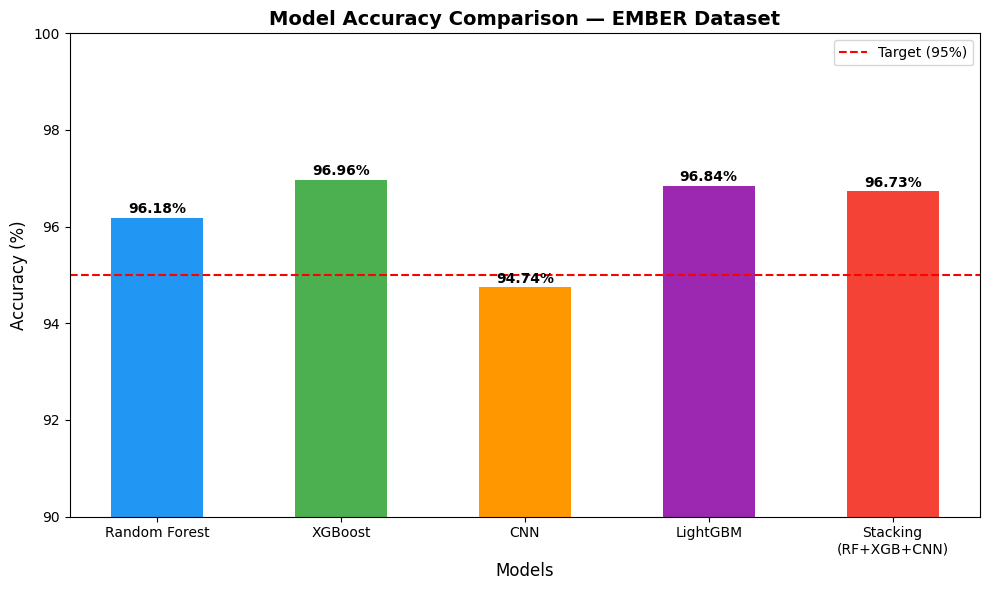

✅ Graph 1 Saved!


In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost', 'CNN', 'LightGBM', 'Stacking\n(RF+XGB+CNN)']
accuracies = [96.18, 96.96, 94.74, 96.84, 96.73]

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336'], width=0.5)
plt.ylim(90, 100)
plt.title('Model Accuracy Comparison — EMBER Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Models', fontsize=12)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc}%', ha='center', fontsize=10, fontweight='bold')
plt.axhline(y=95, color='red', linestyle='--', label='Target (95%)', linewidth=1.5)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Graph 1 Saved!")

k-fold result

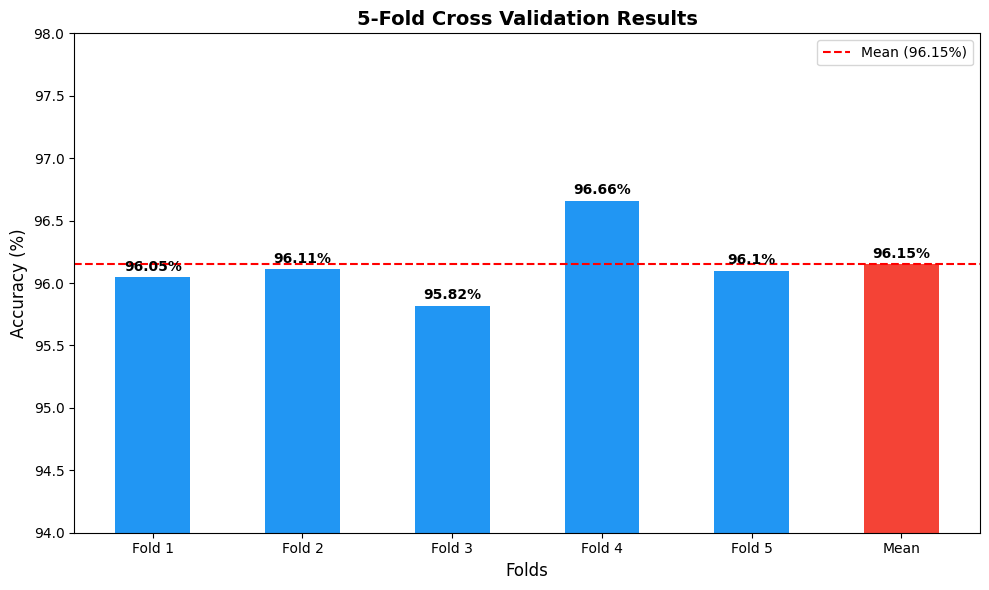

✅ Graph 2 Saved!


In [ ]:
import matplotlib.pyplot as plt

folds = ['Fold 1', 'Fold 2', 'Fold 3', 'Fold 4', 'Fold 5', 'Mean']
accs = [96.05, 96.11, 95.82, 96.66, 96.10, 96.15]
colors = ['#2196F3']*5 + ['#F44336']

plt.figure(figsize=(10, 6))
bars = plt.bar(folds, accs, color=colors, width=0.5)
plt.ylim(94, 98)
plt.title('5-Fold Cross Validation Results', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Folds', fontsize=12)
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{acc}%', ha='center', fontsize=10, fontweight='bold')
plt.axhline(y=96.15, color='red', linestyle='--', label='Mean (96.15%)', linewidth=1.5)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/kfold_graph.png", dpi=150)
plt.show()
print("✅ Graph 2 Saved!")

confusion matrix

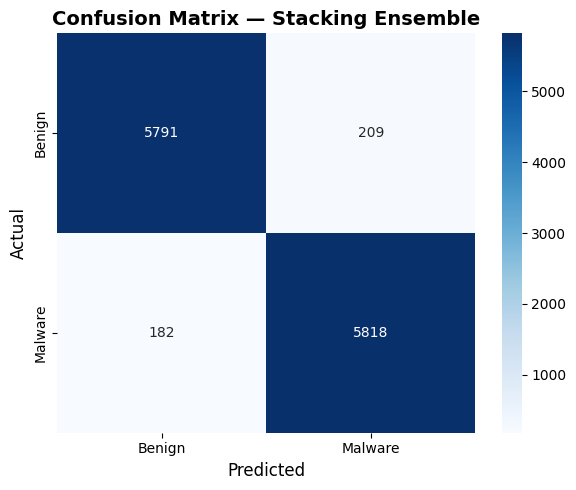

✅ Graph 3 Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib

meta_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/meta_model_lr.pkl")
meta_pred = meta_model.predict(X_test_meta)

cm = confusion_matrix(y_test, meta_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'])
plt.title('Confusion Matrix — Stacking Ensemble', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Graph 3 Saved!")

ROC curve

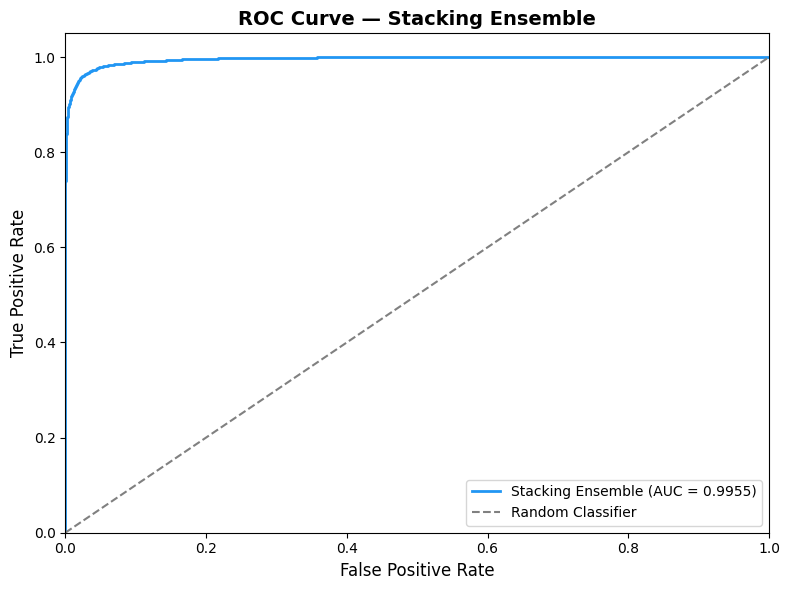

✅ Graph 4 Saved! AUC = 0.9955


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import joblib

meta_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/meta_model_lr.pkl")
meta_prob = meta_model.predict_proba(X_test_meta)[:, 1]

fpr, tpr, _ = roc_curve(y_test, meta_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#2196F3', lw=2, label=f'Stacking Ensemble (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — Stacking Ensemble', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/roc_curve.png", dpi=150)
plt.show()
print(f"✅ Graph 4 Saved! AUC = {roc_auc:.4f}")

shap and lime integration

Calculating SHAP values...
✅ SHAP Values Calculated!


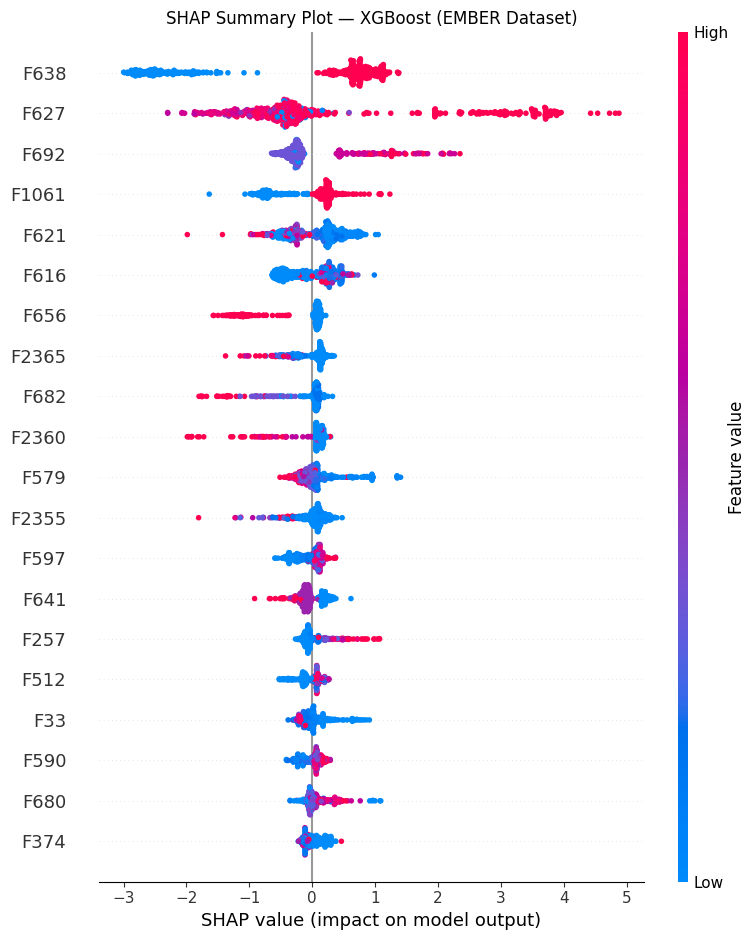

✅ SHAP Summary Plot Saved!


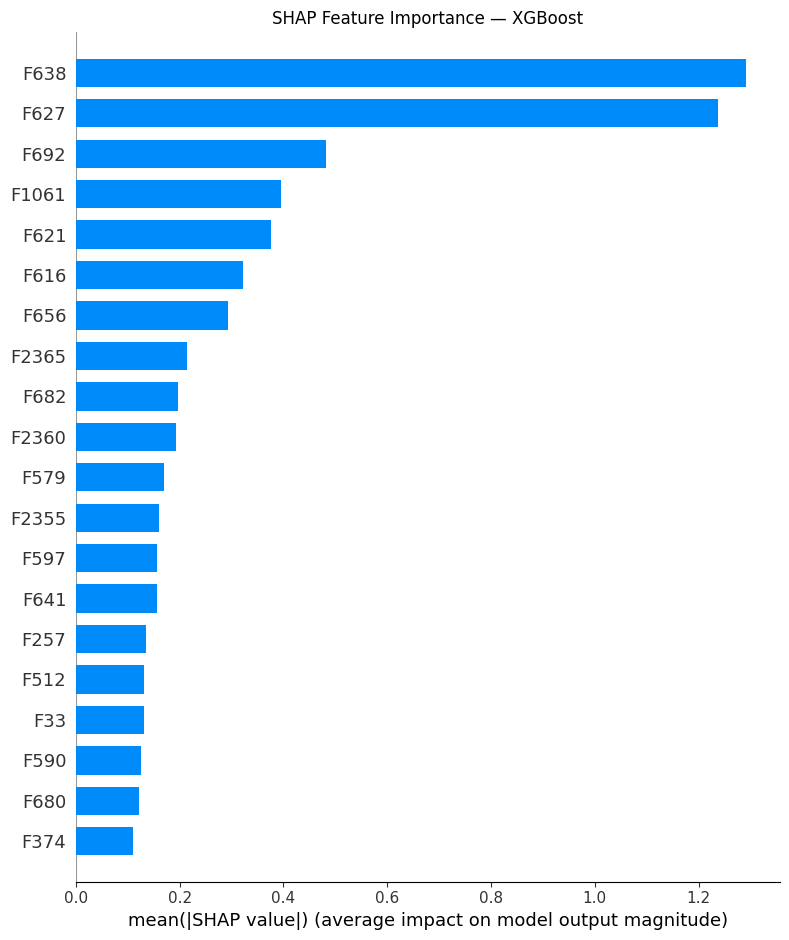

✅ SHAP Bar Plot Saved!


In [ ]:
import shap
import matplotlib.pyplot as plt

print("Calculating SHAP values...")

# XGBoost SHAP — TreeExplainer (fast hota hai)
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test[:500])  # 500 samples pe chalao
print("✅ SHAP Values Calculated!")

# ================================
# PLOT 1: SHAP Summary Plot
# ================================
plt.figure()
shap.summary_plot(shap_values, X_test[:500], show=False)
plt.title("SHAP Summary Plot — XGBoost (EMBER Dataset)")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Summary Plot Saved!")

# ================================
# PLOT 2: SHAP Bar Plot (Feature Importance)
# ================================
plt.figure()
shap.summary_plot(shap_values, X_test[:500], plot_type="bar", show=False)
plt.title("SHAP Feature Importance — XGBoost")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_bar.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP Bar Plot Saved!")

shap force plot

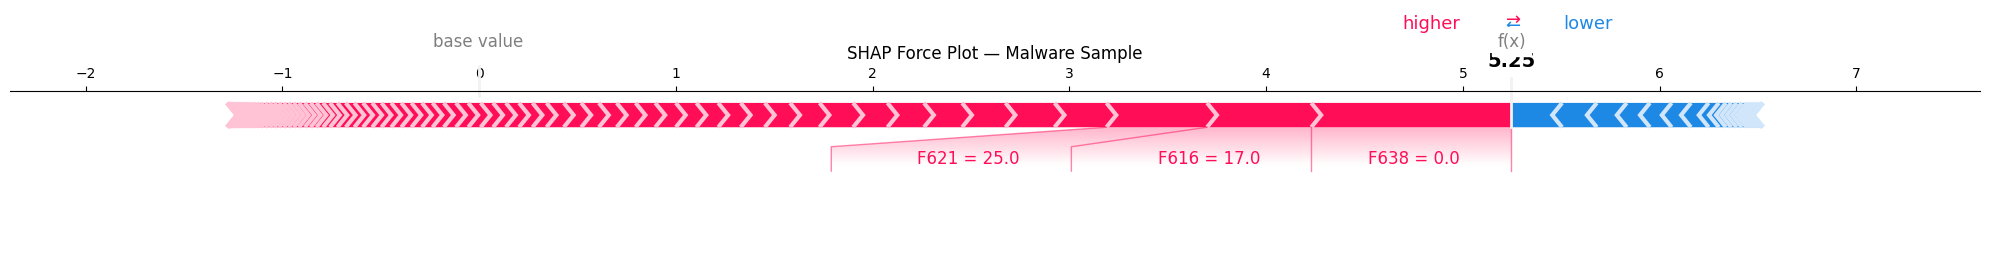

✅ Force Plot Saved!


In [ ]:
# PLOT 3: SHAP Force Plot — Single Sample
shap.initjs()

# Ek malware sample ka explanation
malware_idx = np.where(y_test == 1)[0][0]

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[malware_idx],
    X_test.iloc[malware_idx],
    show=False,
    matplotlib=True
)
plt.title("SHAP Force Plot — Malware Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_force_malware.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Force Plot Saved!")

Ananlysis

In [ ]:
import numpy as np

# Top 10 important features nikalo
feature_names = X_test.columns.tolist()
shap_importance = np.abs(shap_values).mean(axis=0)
top_10_idx = np.argsort(shap_importance)[-10:][::-1]

print("=== Top 10 Important Features (SHAP) ===")
for i, idx in enumerate(top_10_idx):
    print(f"{i+1}. {feature_names[idx]} — SHAP Value: {shap_importance[idx]:.4f}")

# Save karo
import pandas as pd
shap_df = pd.DataFrame({
    'Feature': [feature_names[i] for i in top_10_idx],
    'SHAP_Importance': [shap_importance[i] for i in top_10_idx]
})
shap_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/shap_importance.csv", index=False)
print("\n✅ SHAP Importance Saved!")
print(shap_df)

=== Top 10 Important Features (SHAP) ===
1. F638 — SHAP Value: 1.2924
2. F627 — SHAP Value: 1.2366
3. F692 — SHAP Value: 0.4820
4. F1061 — SHAP Value: 0.3955
5. F621 — SHAP Value: 0.3761
6. F616 — SHAP Value: 0.3213
7. F656 — SHAP Value: 0.2934
8. F2365 — SHAP Value: 0.2134
9. F682 — SHAP Value: 0.1970
10. F2360 — SHAP Value: 0.1926

✅ SHAP Importance Saved!
  Feature  SHAP_Importance
0    F638         1.292403
1    F627         1.236610
2    F692         0.481964
3   F1061         0.395452
4    F621         0.376118
5    F616         0.321268
6    F656         0.293396
7   F2365         0.213441
8    F682         0.196965
9   F2360         0.192603


summary plot

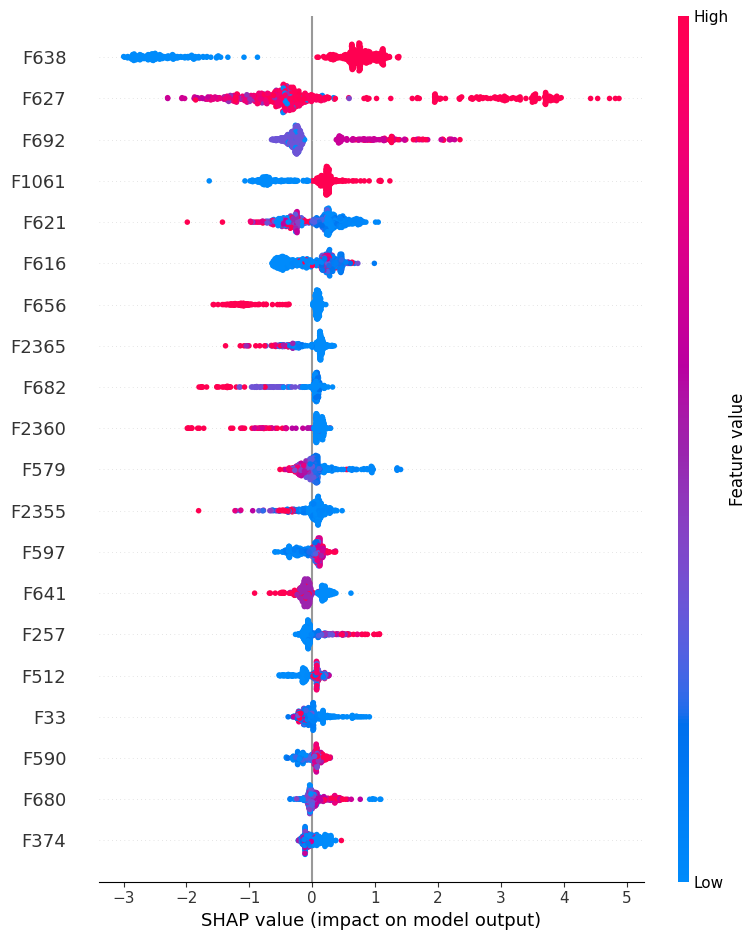

✅ Summary Plot Saved!


In [ ]:
import matplotlib.pyplot as plt
import shap

plt.figure()
shap.summary_plot(shap_values, X_test[:500], show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_summary_beeswarm.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Summary Plot Saved!")

lime

In [ ]:
!pip install lime

import lime
import lime.lime_tabular
import numpy as np

# LIME Explainer
print("Setting up LIME...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train),
    feature_names=X_train.columns.tolist(),
    class_names=['Benign', 'Malware'],
    mode='classification'
)
print("✅ LIME Explainer Ready!")

# Malware sample explain karo
malware_idx = np.where(y_test == 1)[0][0]
sample = np.array(X_test.iloc[malware_idx])

print("Explaining sample...")
lime_exp = lime_explainer.explain_instance(
    sample,
    xgb_model.predict_proba,
    num_features=10
)

# Results print karo
print("\n=== LIME Explanation — Malware Sample ===")
for feature, weight in lime_exp.as_list():
    print(f"{feature} → {weight:.4f}")

# Save karo
lime_exp.save_to_file("/content/drive/MyDrive/XC_MD_Project/results/lime_explanation.html")
print("\n✅ LIME Explanation Saved!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=61454b4a03b038d983e75633c5fee579986605f06f698b146d2f24416eaf493c
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
Setting up LIME...
✅ LIME Explainer Ready!
Explaining sample...

=== LIME Explanation — Malware Sample ===
-1.00 < F638 <= 0.00 → -0.1977
0.00 < F1061 <= 1.00 → 0.1385
F2361 <= 0.00 → 0.1339
F2365 <= 0.00 → 0.0968
F692 <= 1.00 → -0.0808
F2360 <= 0.00 → 0.0770
F656 <= -1.00 → -0.0542
F33 <= 0.00 → 0.0461
F87 > 0.00 → 0.0392
F579 <= 0.00 → 0.0336

✅ LIME Explanation Saved!


lime plot

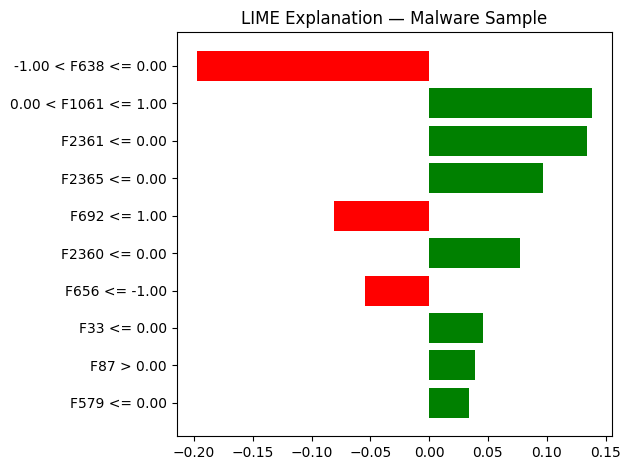

✅ LIME Plot Saved!


In [ ]:
import matplotlib.pyplot as plt

# LIME Plot
fig = lime_exp.as_pyplot_figure()
plt.title("LIME Explanation — Malware Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/lime_plot.png",
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME Plot Saved!")

comparison between shap and lime

In [ ]:
import pandas as pd

# SHAP top features
shap_features = ['F638', 'F627', 'F692', 'F1061', 'F621', 'F616', 'F656', 'F2365', 'F682', 'F2360']
shap_values_list = [1.2924, 1.2366, 0.4820, 0.3955, 0.3761, 0.3213, 0.2934, 0.2134, 0.1970, 0.1926]

# LIME top features
lime_features = ['F638', 'F1061', 'F2361', 'F2365', 'F692', 'F2360', 'F656', 'F33', 'F87', 'F579']
lime_values_list = [0.1977, 0.1385, 0.1339, 0.0968, 0.0808, 0.0770, 0.0542, 0.0461, 0.0392, 0.0336]

# Common features
common = set(shap_features) & set(lime_features)
print(f"✅ Common Important Features: {common}")

# SHAP DataFrame save
shap_df = pd.DataFrame({
    'Feature': shap_features,
    'SHAP_Importance': shap_values_list
})
shap_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/shap_top10.csv", index=False)
print("✅ SHAP Top 10 Saved!")

# LIME DataFrame save
lime_df = pd.DataFrame({
    'Feature': lime_features,
    'LIME_Weight': lime_values_list
})
lime_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/lime_top10.csv", index=False)
print("✅ LIME Top 10 Saved!")

# Comparison DataFrame save
shap_set = set(shap_features)
lime_set = set(lime_features)
common = shap_set & lime_set
only_shap = shap_set - lime_set
only_lime = lime_set - shap_set

comparison_df = pd.DataFrame({
    'Feature': list(common) + list(only_shap) + list(only_lime),
    'In_SHAP': [True]*len(common) + [True]*len(only_shap) + [False]*len(only_lime),
    'In_LIME': [True]*len(common) + [False]*len(only_shap) + [True]*len(only_lime),
    'Category': ['Common']*len(common) + ['SHAP Only']*len(only_shap) + ['LIME Only']*len(only_lime)
})
comparison_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/shap_lime_comparison.csv", index=False)
print("✅ SHAP vs LIME Comparison Saved!")

print("\n=== Summary ===")
print(f"Common Features: {common}")
print(f"SHAP Only: {only_shap}")
print(f"LIME Only: {only_lime}")

✅ Common Important Features: {'F2360', 'F2365', 'F1061', 'F638', 'F656', 'F692'}
✅ SHAP Top 10 Saved!
✅ LIME Top 10 Saved!
✅ SHAP vs LIME Comparison Saved!

=== Summary ===
Common Features: {'F2360', 'F2365', 'F1061', 'F638', 'F656', 'F692'}
SHAP Only: {'F621', 'F616', 'F627', 'F682'}
LIME Only: {'F2361', 'F87', 'F579', 'F33'}


final model evaluation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report
import tensorflow as tf
import joblib

# Load data
print("Loading data...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Data Loaded!")

# Models load karo
rf_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/XC_MD_Project/models/cnn_model.h5")
meta_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/meta_model_lr.pkl")
print("✅ Models Loaded!")

# CNN ke liye normalize + reshape
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)
X_train_cnn = X_train_scaled.reshape(-1, 100, 1)
X_test_cnn = X_test_scaled.reshape(-1, 100, 1)

# Base predictions
print("Getting predictions...")
rf_train_pred = rf_model.predict_proba(X_train_selected)[:, 1]
xgb_train_pred = xgb_model.predict_proba(X_train_selected)[:, 1]
cnn_train_pred = cnn_model.predict(X_train_cnn).ravel()

rf_test_pred = rf_model.predict_proba(X_test_selected)[:, 1]
xgb_test_pred = xgb_model.predict_proba(X_test_selected)[:, 1]
cnn_test_pred = cnn_model.predict(X_test_cnn).ravel()

# Meta features
X_train_meta = np.column_stack([rf_train_pred, xgb_train_pred, cnn_train_pred])
X_test_meta = np.column_stack([rf_test_pred, xgb_test_pred, cnn_test_pred])
print(f"✅ Meta Features Ready: {X_test_meta.shape}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
✅ Data Loaded!


✅ Models Loaded!
Getting predictions...
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
✅ Meta Features Ready: (12000, 3)


In [ ]:
# Predictions
meta_pred = meta_model.predict(X_test_meta)
meta_prob = meta_model.predict_proba(X_test_meta)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, meta_pred)
precision = precision_score(y_test, meta_pred)
recall = recall_score(y_test, meta_pred)
f1 = f1_score(y_test, meta_pred)
auc = roc_auc_score(y_test, meta_prob)

print("=== Final Stacking Ensemble Metrics ===")
print(f"Accuracy  : {accuracy*100:.2f}%")
print(f"Precision : {precision*100:.2f}%")
print(f"Recall    : {recall*100:.2f}%")
print(f"F1-Score  : {f1*100:.2f}%")
print(f"AUC       : {auc:.4f}")
print(f"\n{classification_report(y_test, meta_pred, target_names=['Benign', 'Malware'])}")

# Save
metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC'],
    'Value': [f"{accuracy*100:.2f}%", f"{precision*100:.2f}%",
              f"{recall*100:.2f}%", f"{f1*100:.2f}%", f"{auc:.4f}"]
})
metrics_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/final_metrics.csv", index=False)
print("✅ Metrics Saved!")

=== Final Stacking Ensemble Metrics ===
Accuracy  : 96.74%
Precision : 96.53%
Recall    : 96.97%
F1-Score  : 96.75%
AUC       : 0.9955

              precision    recall  f1-score   support

      Benign       0.97      0.97      0.97      6000
     Malware       0.97      0.97      0.97      6000

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000

✅ Metrics Saved!


ablation testing

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import numpy as np

print("=== Ablation Study ===\n")

# Full Model
full_meta = np.column_stack([rf_test_pred, xgb_test_pred, cnn_test_pred])
full_model = LogisticRegression(C=10, random_state=42, max_iter=1000)
full_model.fit(np.column_stack([rf_train_pred, xgb_train_pred, cnn_train_pred]), y_train)
full_acc = accuracy_score(y_test, full_model.predict(full_meta))
print(f"RF + XGBoost + CNN : {full_acc*100:.2f}%")

# Without RF
no_rf_meta = np.column_stack([xgb_test_pred, cnn_test_pred])
no_rf_model = LogisticRegression(C=10, random_state=42, max_iter=1000)
no_rf_model.fit(np.column_stack([xgb_train_pred, cnn_train_pred]), y_train)
no_rf_acc = accuracy_score(y_test, no_rf_model.predict(no_rf_meta))
print(f"XGBoost + CNN (No RF) : {no_rf_acc*100:.2f}% | Drop: {(full_acc-no_rf_acc)*100:.2f}%")

# Without XGBoost
no_xgb_meta = np.column_stack([rf_test_pred, cnn_test_pred])
no_xgb_model = LogisticRegression(C=10, random_state=42, max_iter=1000)
no_xgb_model.fit(np.column_stack([rf_train_pred, cnn_train_pred]), y_train)
no_xgb_acc = accuracy_score(y_test, no_xgb_model.predict(no_xgb_meta))
print(f"RF + CNN (No XGBoost) : {no_xgb_acc*100:.2f}% | Drop: {(full_acc-no_xgb_acc)*100:.2f}%")

# Without CNN
no_cnn_meta = np.column_stack([rf_test_pred, xgb_test_pred])
no_cnn_model = LogisticRegression(C=10, random_state=42, max_iter=1000)
no_cnn_model.fit(np.column_stack([rf_train_pred, xgb_train_pred]), y_train)
no_cnn_acc = accuracy_score(y_test, no_cnn_model.predict(no_cnn_meta))
print(f"RF + XGBoost (No CNN) : {no_cnn_acc*100:.2f}% | Drop: {(full_acc-no_cnn_acc)*100:.2f}%")

# Save
import pandas as pd
ablation_df = pd.DataFrame({
    'Combination': ['RF + XGBoost + CNN', 'XGBoost + CNN (No RF)', 'RF + CNN (No XGBoost)', 'RF + XGBoost (No CNN)'],
    'Accuracy': [f"{full_acc*100:.2f}%", f"{no_rf_acc*100:.2f}%", f"{no_xgb_acc*100:.2f}%", f"{no_cnn_acc*100:.2f}%"],
    'Drop': ["—", f"{(full_acc-no_rf_acc)*100:.2f}%", f"{(full_acc-no_xgb_acc)*100:.2f}%", f"{(full_acc-no_cnn_acc)*100:.2f}%"]
})
ablation_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/ablation_results.csv", index=False)
print(f"\n✅ Ablation Results Saved!")
print(ablation_df)

=== Ablation Study ===

RF + XGBoost + CNN : 96.26%
XGBoost + CNN (No RF) : 96.98% | Drop: -0.72%
RF + CNN (No XGBoost) : 96.12% | Drop: 0.14%
RF + XGBoost (No CNN) : 96.29% | Drop: -0.03%

✅ Ablation Results Saved!
             Combination Accuracy    Drop
0     RF + XGBoost + CNN   96.26%       —
1  XGBoost + CNN (No RF)   96.98%  -0.72%
2  RF + CNN (No XGBoost)   96.12%   0.14%
3  RF + XGBoost (No CNN)   96.29%  -0.03%


ember feature extractor

In [ ]:
# EMBER ka feature extractor use karo
import sys
sys.path.append('/content/ember')
import ember

def predict_ember(file_path):
    # EMBER features extract karo
    features = ember.features.PEFeatureExtractor(2)
    raw_features = features.raw_features(open(file_path, 'rb').read())
    feature_vector = features.process_raw_features(raw_features)
    return feature_vector

print("✅ EMBER Feature Extractor Ready!")

✅ EMBER Feature Extractor Ready!


Step 1: Precision-Recall Curve

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading data...
✅ Data Loaded!


✅ Models Loaded!
Getting predictions...
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
✅ Meta Features Ready!


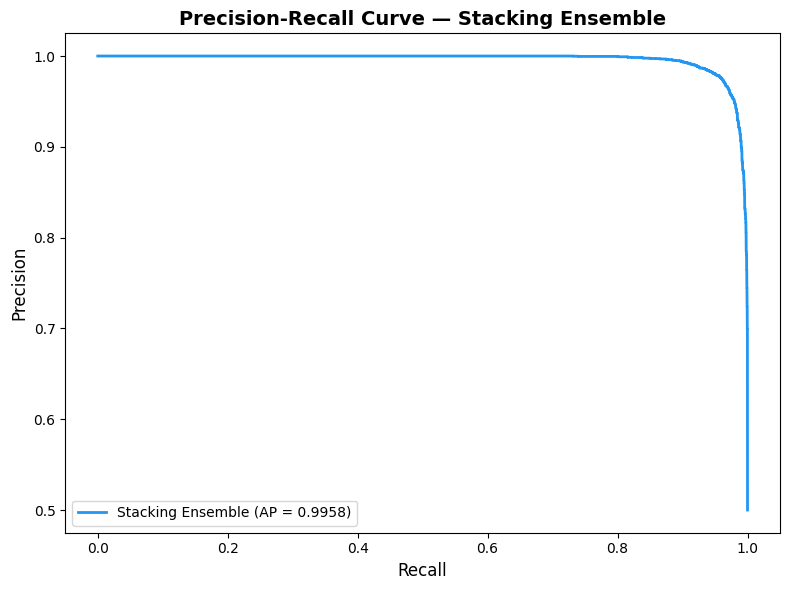

✅ Saved! AP = 0.9958


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_recall_curve, average_precision_score
import tensorflow as tf
import joblib
import matplotlib.pyplot as plt

# Load data
print("Loading data...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
print(f"✅ Data Loaded!")

# Models load
rf_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/rf_model.pkl")
xgb_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
cnn_model = tf.keras.models.load_model("/content/drive/MyDrive/XC_MD_Project/models/cnn_model.h5")
meta_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/meta_model_lr.pkl")
print("✅ Models Loaded!")

# CNN normalize + reshape
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)
X_train_cnn = X_train_scaled.reshape(-1, 100, 1)
X_test_cnn = X_test_scaled.reshape(-1, 100, 1)

# Base predictions
print("Getting predictions...")
rf_train_pred = rf_model.predict_proba(X_train_selected)[:, 1]
xgb_train_pred = xgb_model.predict_proba(X_train_selected)[:, 1]
cnn_train_pred = cnn_model.predict(X_train_cnn).ravel()

rf_test_pred = rf_model.predict_proba(X_test_selected)[:, 1]
xgb_test_pred = xgb_model.predict_proba(X_test_selected)[:, 1]
cnn_test_pred = cnn_model.predict(X_test_cnn).ravel()

X_train_meta = np.column_stack([rf_train_pred, xgb_train_pred, cnn_train_pred])
X_test_meta = np.column_stack([rf_test_pred, xgb_test_pred, cnn_test_pred])
print(f"✅ Meta Features Ready!")

# Precision-Recall Curve
meta_prob = meta_model.predict_proba(X_test_meta)[:, 1]
precision, recall, _ = precision_recall_curve(y_test, meta_prob)
avg_precision = average_precision_score(y_test, meta_prob)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='#2196F3', lw=2,
         label=f'Stacking Ensemble (AP = {avg_precision:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — Stacking Ensemble', fontsize=14, fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/precision_recall_curve.png", dpi=150)
plt.show()
print(f"✅ Saved! AP = {avg_precision:.4f}")

Step 2 — LIME Benign Sample Pe Bhi Karo:

In [6]:
!pip install lime
print("✅ LIME Installed!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=5ccd708850a31d0a463d905137e2ed4ae9e7a95e598ed63ae5f761e74d94ea08
  Stored in directory: /root/.cache/pip/wheels/e7/5d/0e/4b4fff9a47468fed5633211fb3b76d1db43fe806a17fb7486a
Successfully built lime
✅ LIME Installed!


=== LIME — Malware Sample ===
-1.00 < F638 <= 0.00 → -0.1859
0.00 < F1061 <= 1.00 → 0.1304
F2361 <= 0.00 → 0.1146
F692 <= 1.00 → -0.0965
F2365 <= 0.00 → 0.0859
F2360 <= 0.00 → 0.0829
F656 <= -1.00 → -0.0691
F87 > 0.00 → 0.0572
F597 > 0.01 → 0.0513
F616 > 11.00 → 0.0458


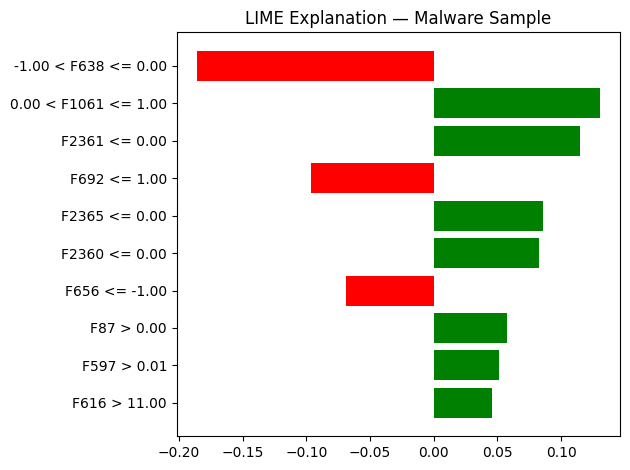

✅ LIME Malware Saved!

=== LIME — Benign Sample ===
F638 <= -1.00 → 0.1928
F1061 <= 0.00 → -0.1409
F2361 <= 0.00 → 0.1242
F692 <= 1.00 → -0.1015
F2360 <= 0.00 → 0.0881
F627 <= 1240393900.00 → -0.0558
F682 > 5.00 → -0.0507
F257 <= 0.00 → -0.0451
F616 <= 1.00 → -0.0439
F215 <= 0.00 → -0.0421


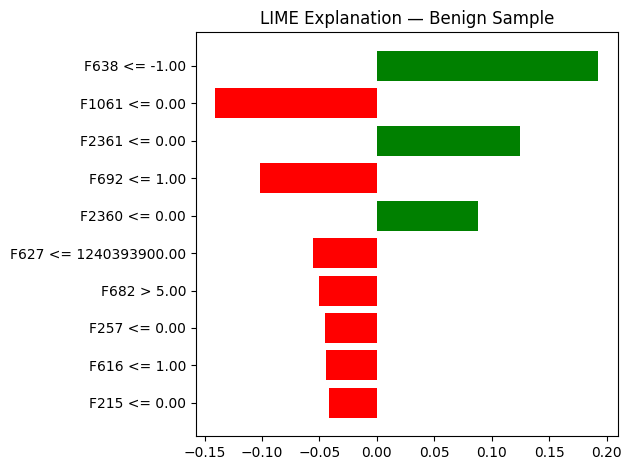

✅ LIME Benign Saved!


In [7]:
import lime
import lime.lime_tabular
import numpy as np
import matplotlib.pyplot as plt

# LIME Explainer
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_selected),
    feature_names=X_train_selected.columns.tolist(),
    class_names=['Benign', 'Malware'],
    mode='classification'
)

# ================================
# Malware Sample
# ================================
malware_idx = np.where(y_test == 1)[0][0]
lime_malware = lime_explainer.explain_instance(
    np.array(X_test_selected.iloc[malware_idx]),
    xgb_model.predict_proba,
    num_features=10
)
print("=== LIME — Malware Sample ===")
for feature, weight in lime_malware.as_list():
    print(f"{feature} → {weight:.4f}")

fig = lime_malware.as_pyplot_figure()
plt.title("LIME Explanation — Malware Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/lime_malware.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME Malware Saved!")

# ================================
# Benign Sample
# ================================
benign_idx = np.where(y_test == 0)[0][0]
lime_benign = lime_explainer.explain_instance(
    np.array(X_test_selected.iloc[benign_idx]),
    xgb_model.predict_proba,
    num_features=10
)
print("\n=== LIME — Benign Sample ===")
for feature, weight in lime_benign.as_list():
    print(f"{feature} → {weight:.4f}")

fig = lime_benign.as_pyplot_figure()
plt.title("LIME Explanation — Benign Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/lime_benign.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ LIME Benign Saved!")

 SHAP vs LIME Comparison Plot:

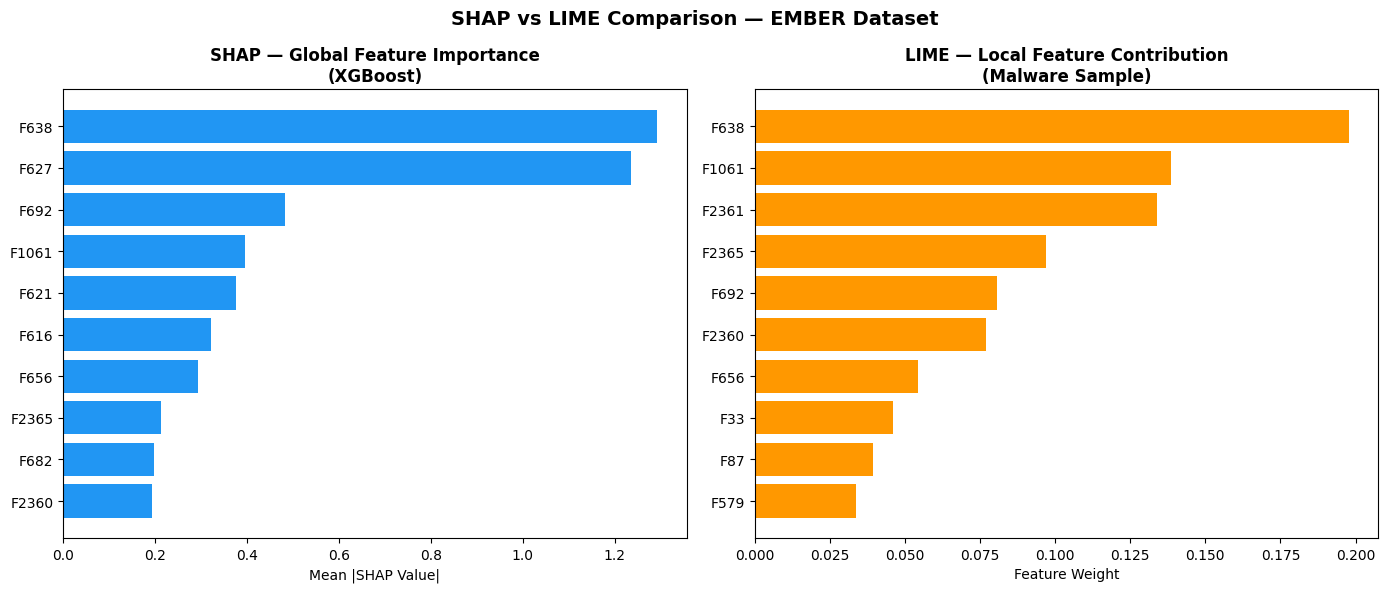

✅ SHAP vs LIME Comparison Plot Saved!

✅ Common Features (Both Agree): {'F1061', 'F692', 'F2365', 'F638', 'F2360', 'F656'}


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# SHAP Top 10 features aur values
shap_features = ['F638', 'F627', 'F692', 'F1061', 'F621', 'F616', 'F656', 'F2365', 'F682', 'F2360']
shap_vals = [1.2924, 1.2366, 0.4820, 0.3955, 0.3761, 0.3213, 0.2934, 0.2134, 0.1970, 0.1926]

# LIME Top 10 features aur values
lime_features = ['F638', 'F1061', 'F2361', 'F2365', 'F692', 'F2360', 'F656', 'F33', 'F87', 'F579']
lime_vals = [0.1977, 0.1385, 0.1339, 0.0968, 0.0808, 0.0770, 0.0542, 0.0461, 0.0392, 0.0336]

# Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# SHAP Bar
ax1.barh(shap_features[::-1], shap_vals[::-1], color='#2196F3')
ax1.set_title('SHAP — Global Feature Importance\n(XGBoost)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean |SHAP Value|')

# LIME Bar
ax2.barh(lime_features[::-1], lime_vals[::-1], color='#FF9800')
ax2.set_title('LIME — Local Feature Contribution\n(Malware Sample)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature Weight')

plt.suptitle('SHAP vs LIME Comparison — EMBER Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_vs_lime_comparison.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ SHAP vs LIME Comparison Plot Saved!")

# Common features highlight karo
common = set(shap_features) & set(lime_features)
print(f"\n✅ Common Features (Both Agree): {common}")

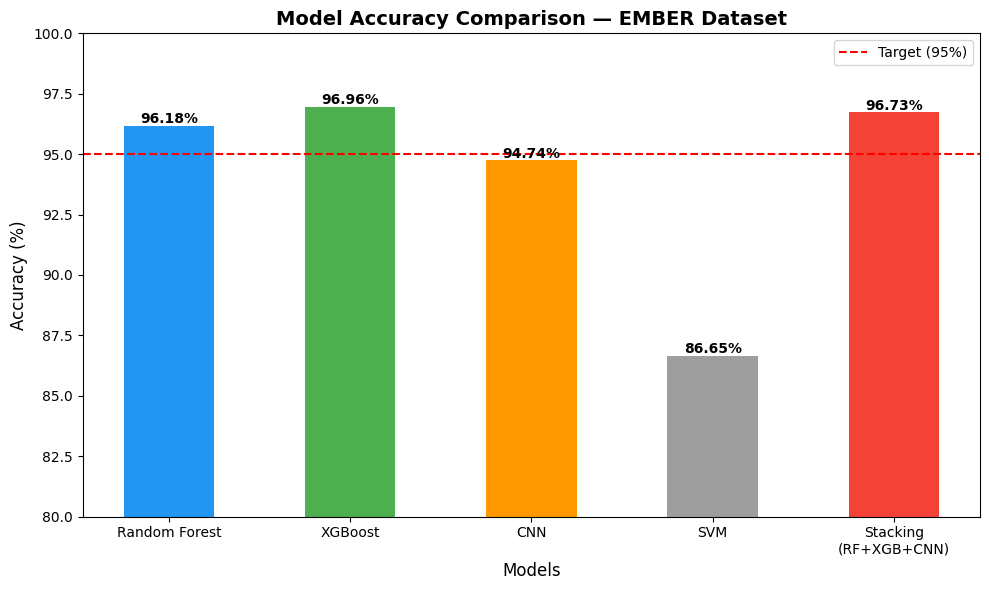

✅ Graph Updated!


In [ ]:
import matplotlib.pyplot as plt

models = ['Random Forest', 'XGBoost', 'CNN', 'SVM', 'Stacking\n(RF+XGB+CNN)']
accuracies = [96.18, 96.96, 94.74, 86.65, 96.73]
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9E9E9E', '#F44336']

plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracies, color=colors, width=0.5)
plt.ylim(80, 100)
plt.title('Model Accuracy Comparison — EMBER Dataset', fontsize=14, fontweight='bold')
plt.ylabel('Accuracy (%)', fontsize=12)
plt.xlabel('Models', fontsize=12)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc}%', ha='center', fontsize=10, fontweight='bold')
plt.axhline(y=95, color='red', linestyle='--', label='Target (95%)', linewidth=1.5)
plt.legend()
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/accuracy_comparison.png", dpi=150)
plt.show()
print("✅ Graph Updated!")

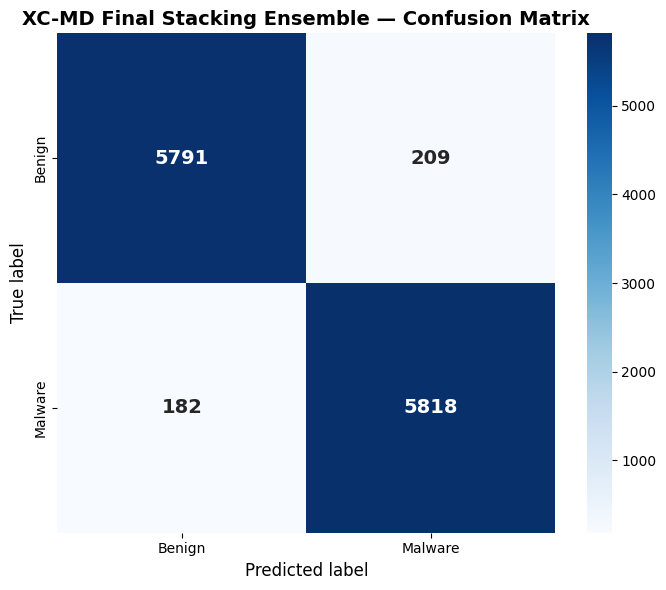

✅ Confusion Matrix Saved!


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import joblib
import numpy as np

# Predictions
meta_pred = meta_model.predict(X_test_meta)

# Confusion Matrix
cm = confusion_matrix(y_test, meta_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            annot_kws={"size": 14, "weight": "bold"})
plt.title('XC-MD Final Stacking Ensemble — Confusion Matrix', fontsize=14, fontweight='bold')
plt.ylabel('True label', fontsize=12)
plt.xlabel('Predicted label', fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/confusion_matrix.png", dpi=150)
plt.show()
print("✅ Confusion Matrix Saved!")

prediction func

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
print("MyDrive contents:")
for f in os.listdir("/content/drive/MyDrive/"):
    print(f)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
MyDrive contents:
Colab Notebooks
Ananya aggarwal -certificates
b4bc4f45-780c-43f1-ac43-6d1b6c41a9ca.pdf
XC_MD_Project


In [3]:
import pandas as pd
import numpy as np
import joblib
import shap
import json

# Load data
print("Loading...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_train = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_train_new.csv").values.ravel()
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
xgb_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
print("✅ Loaded!")

# SHAP calculate
print("Calculating SHAP values...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_selected[:500])
print("✅ SHAP Done!")

# Save SHAP files
np.save("/content/drive/MyDrive/XC_MD_Project/results/shap_values_xgb.npy", shap_values)

feature_names = X_test_selected.columns.tolist()
with open("/content/drive/MyDrive/XC_MD_Project/results/top_feature_names.json", "w") as f:
    json.dump(feature_names, f)

print("✅ SHAP Files Saved!")
print(f"shap_values shape: {shap_values.shape}")
print(f"feature_names count: {len(feature_names)}")

Loading...
✅ Loaded!
Calculating SHAP values...
✅ SHAP Done!
✅ SHAP Files Saved!
shap_values shape: (500, 100)
feature_names count: 100


In [8]:
import os
import numpy as np
import pandas as pd
import joblib
import shap
import json
import lime
import lime.lime_tabular
import matplotlib.pyplot as plt

# ================================
# STEP 1: LOAD DATA & MODELS
# ================================
print("Loading...")
X_train_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_train_selected_new.csv")
X_test_selected = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/X_test_selected_new.csv")
y_test = pd.read_csv("/content/drive/MyDrive/XC_MD_Project/preprocessing/y_test_new.csv").values.ravel()
xgb_model = joblib.load("/content/drive/MyDrive/XC_MD_Project/models/xgb_model.pkl")
print("✅ Loaded!")

# ================================
# STEP 2: SHAP SAVE
# ================================
print("Calculating SHAP...")
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_selected[:500])
np.save("/content/drive/MyDrive/XC_MD_Project/results/shap_values_xgb.npy", shap_values)
feature_names = X_test_selected.columns.tolist()
with open("/content/drive/MyDrive/XC_MD_Project/results/top_feature_names.json", "w") as f:
    json.dump(feature_names, f)
print("✅ SHAP Saved!")

# ================================
# STEP 3: SHAP PLOTS SAVE
# ================================
# Bar plot
plt.figure()
shap.summary_plot(shap_values, X_test_selected[:500], plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_bar.png", dpi=150, bbox_inches='tight')
plt.close()

# Beeswarm plot
plt.figure()
shap.summary_plot(shap_values, X_test_selected[:500], show=False)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_beeswarm.png", dpi=150, bbox_inches='tight')
plt.close()
print("✅ SHAP Plots Saved!")

# ================================
# STEP 4: LIME SAVE
# ================================
print("Running LIME...")
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_train_selected),
    feature_names=feature_names,
    class_names=['Benign', 'Malware'],
    mode='classification'
)

# Malware sample
malware_idx = np.where(y_test == 1)[0][0]
lime_malware = lime_explainer.explain_instance(
    np.array(X_test_selected.iloc[malware_idx]),
    xgb_model.predict_proba,
    num_features=10
)
lime_malware.save_to_file("/content/drive/MyDrive/XC_MD_Project/results/lime_malware.html")

# Malware plot
fig = lime_malware.as_pyplot_figure()
plt.title("LIME — Malware Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/lime_malware.png", dpi=150, bbox_inches='tight')
plt.close()

# Benign sample
benign_idx = np.where(y_test == 0)[0][0]
lime_benign = lime_explainer.explain_instance(
    np.array(X_test_selected.iloc[benign_idx]),
    xgb_model.predict_proba,
    num_features=10
)
lime_benign.save_to_file("/content/drive/MyDrive/XC_MD_Project/results/lime_benign.html")

# Benign plot
fig = lime_benign.as_pyplot_figure()
plt.title("LIME — Benign Sample")
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/lime_benign.png", dpi=150, bbox_inches='tight')
plt.close()
print("✅ LIME Saved!")

# ================================
# STEP 5: SHAP vs LIME COMPARISON
# ================================
shap_importance = np.abs(shap_values).mean(axis=0)
top_10_idx = np.argsort(shap_importance)[-10:][::-1]
shap_features = [feature_names[i] for i in top_10_idx]
shap_vals = [shap_importance[i] for i in top_10_idx]

lime_features = [f for f, _ in lime_malware.as_list()]
lime_vals = [abs(w) for _, w in lime_malware.as_list()]

# Comparison plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
ax1.barh(shap_features[::-1], shap_vals[::-1], color='#2196F3')
ax1.set_title('SHAP — Global Feature Importance\n(XGBoost)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Mean |SHAP Value|')
ax2.barh(lime_features[::-1], lime_vals[::-1], color='#FF9800')
ax2.set_title('LIME — Local Feature Contribution\n(Malware Sample)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Feature Weight')
plt.suptitle('SHAP vs LIME Comparison — EMBER Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/XC_MD_Project/results/shap_vs_lime_comparison.png", dpi=150, bbox_inches='tight')
plt.close()

# Save comparison CSV
common = set(shap_features) & set(lime_features)
comparison_df = pd.DataFrame({
    'Feature': list(common) + list(set(shap_features)-set(lime_features)) + list(set(lime_features)-set(shap_features)),
    'In_SHAP': [True]*len(common) + [True]*len(set(shap_features)-set(lime_features)) + [False]*len(set(lime_features)-set(shap_features)),
    'In_LIME': [True]*len(common) + [False]*len(set(shap_features)-set(lime_features)) + [True]*len(set(lime_features)-set(shap_features)),
    'Category': ['Common']*len(common) + ['SHAP Only']*len(set(shap_features)-set(lime_features)) + ['LIME Only']*len(set(lime_features)-set(shap_features))
})
comparison_df.to_csv("/content/drive/MyDrive/XC_MD_Project/results/shap_lime_comparison.csv", index=False)
print("✅ SHAP vs LIME Comparison Saved!")

# ================================
# STEP 6: VERIFY ALL FILES
# ================================
print("\n=== All Saved Files ===")
for f in sorted(os.listdir("/content/drive/MyDrive/XC_MD_Project/results/")):
    print(f"  ✅ {f}")

Loading...
✅ Loaded!
Calculating SHAP...
✅ SHAP Saved!
✅ SHAP Plots Saved!
Running LIME...
✅ LIME Saved!
✅ SHAP vs LIME Comparison Saved!

=== All Saved Files ===
  ✅ ablation_results.csv
  ✅ accuracy_comparison.png
  ✅ baseline_results.csv
  ✅ cm_rf.png
  ✅ cm_xgb.png
  ✅ confusion_matrix.png
  ✅ confusion_matrix_stacking.png
  ✅ final_metrics.csv
  ✅ kfold_graph.png
  ✅ kfold_results.csv
  ✅ kfold_results.png
  ✅ lime_benign.html
  ✅ lime_benign.png
  ✅ lime_explanation.html
  ✅ lime_malware.html
  ✅ lime_malware.png
  ✅ lime_plot.png
  ✅ lime_top10.csv
  ✅ precision_recall_curve.png
  ✅ roc_curve.png
  ✅ shap_bar.png
  ✅ shap_beeswarm.png
  ✅ shap_force_malware.png
  ✅ shap_importance.csv
  ✅ shap_lime_comparison.csv
  ✅ shap_summary.png
  ✅ shap_summary_beeswarm.png
  ✅ shap_top10.csv
  ✅ shap_values_xgb.npy
  ✅ shap_vs_lime_comparison.png
  ✅ top_feature_names.json
